# Демо 6. Собственные колебания цепочки упруго соединённых звеньев

*Источник:* П.А. Кручинин. Об освоении пакета MATLAB с использованием практических задач. Здесь задача переведена на Python.

## Постановка задачи

Цепочка из $N$ звеньев массы $m$ лежит в горизонтальной плоскости. Звенья движутся поступательно вдоль оси $x$ и соединены пружинами жёсткости $c$; крайние звенья соединены с неподвижными опорами. Уравнения собственных колебаний:
$$
\ddot x = C x, \qquad
C = \frac{c}{m}\begin{pmatrix}
-2 & 1 & & \\
1 & -2 & \ddots & \\
 & \ddots & \ddots & 1\\
 & & 1 & -2
\end{pmatrix}.
$$
Требуется найти собственные частоты и формы колебаний и промоделировать собственные колебания при начальных условиях, соответствующих одной из собственных форм.

Собственные частоты — мнимые части собственных чисел матрицы
$$
A = \begin{pmatrix} 0 & I \\ C & 0 \end{pmatrix},
$$
а собственные формы — подвекторы соответствующих собственных векторов.

**Что отрабатываем:** формирование ленточных и блочных матриц (`np.diag`, `np.block`), собственные числа и векторы, моделирование линейной системы (`control.initial_response`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg
import control as ct

m, c, N = 1.0, 1.0, 5

# трёхдиагональная матрица без цикла: главная диагональ и две соседние
Cm = (c / m) * (-2 * np.eye(N) + np.diag(np.ones(N - 1), 1) + np.diag(np.ones(N - 1), -1))
# блочная матрица системы первого порядка
A = np.block([[np.zeros((N, N)), np.eye(N)],
              [Cm,               np.zeros((N, N))]])
print(Cm)

[[-2.  1.  0.  0.  0.]
 [ 1. -2.  1.  0.  0.]
 [ 0.  1. -2.  1.  0.]
 [ 0.  0.  1. -2.  1.]
 [ 0.  0.  0.  1. -2.]]


## Частоты и формы через собственные числа матрицы $A$

Собственные числа $A$ — пары $\pm i\omega_k$. В MATLAB частоты выделялись как `imag(l(1:2:end))`, в расчёте на то, что сопряжённые числа идут парами. **NumPy порядок собственных чисел не гарантирует**, поэтому оставим числа с положительной мнимой частью и упорядочим их.

In [2]:
lam, V = np.linalg.eig(A)
# ВНИМАНИЕ: np.linalg.eig НЕ гарантирует порядок собственных чисел, и сопряжённые
# пары +-i*omega не обязательно идут подряд. Поэтому нельзя, как в MATLAB-версии,
# брать каждое второе число (l(1:2:end)): отбираем числа явно и сортируем.
idx = np.where(lam.imag > 1e-12)[0]          # по одному числу из каждой пары: Im > 0
idx = idx[np.argsort(lam.imag[idx])]         # по возрастанию частоты
omega = lam.imag[idx]
print('собственные частоты:', np.round(omega, 4))

# форма: верхний подвектор (перемещения); собственный вектор определён с точностью
# до комплексного множителя, поэтому поворачиваем его так, чтобы он стал вещественным
shapes = []
for k in idx:
    v = V[:N, k]
    v = v / v[np.argmax(np.abs(v))]           # наибольшая компонента равна 1
    shapes.append(v.real)
shapes = np.array(shapes)

собственные частоты: [0.5176 1.     1.4142 1.7321 1.9319]


Для консервативной системы те же частоты и формы проще найти из симметричной задачи $-C\varphi = \omega^2\varphi$ функцией `scipy.linalg.eigh`: она возвращает вещественные собственные векторы, упорядоченные по возрастанию $\omega^2$. Сравним результаты:

In [3]:
w2, Phi = scipy.linalg.eigh(-Cm)
print('частоты из eigh:', np.round(np.sqrt(w2), 4))
print('совпадают:', np.allclose(np.sqrt(w2), omega))

частоты из eigh: [0.5176 1.     1.4142 1.7321 1.9319]
совпадают: True


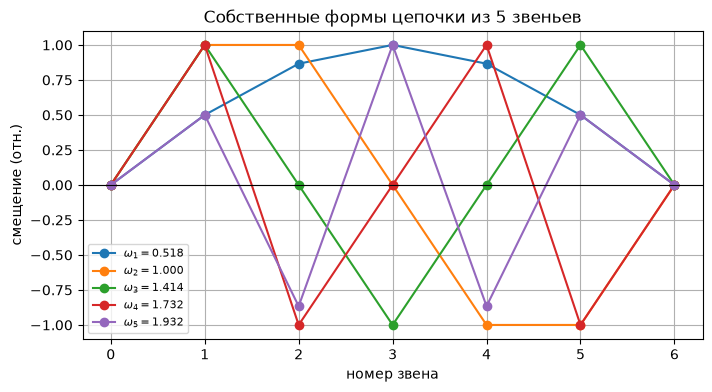

In [4]:
pos = np.arange(N + 2)                        # номера узлов с опорами
fig, ax = plt.subplots(figsize=(8, 4))
for k, (w, phi) in enumerate(zip(omega, shapes), start=1):
    ax.plot(pos, np.r_[0, phi, 0], '-o', label=fr'$\omega_{k} = {w:.3f}$')
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel('номер звена')
ax.set_ylabel('смещение (отн.)')
ax.set_title(f'Собственные формы цепочки из {N} звеньев')
ax.legend(fontsize=8)
ax.grid(True)
plt.show()

## Колебания по собственной форме

Зададим начальные смещения по первой форме с нулевыми скоростями и промоделируем свободное движение функцией `control.initial_response` (аналог `initial` в MATLAB). Если начальные условия совпадают с собственной формой, все звенья колеблются синфазно с одной частотой $\omega_1$, а форма цепочки сохраняется.

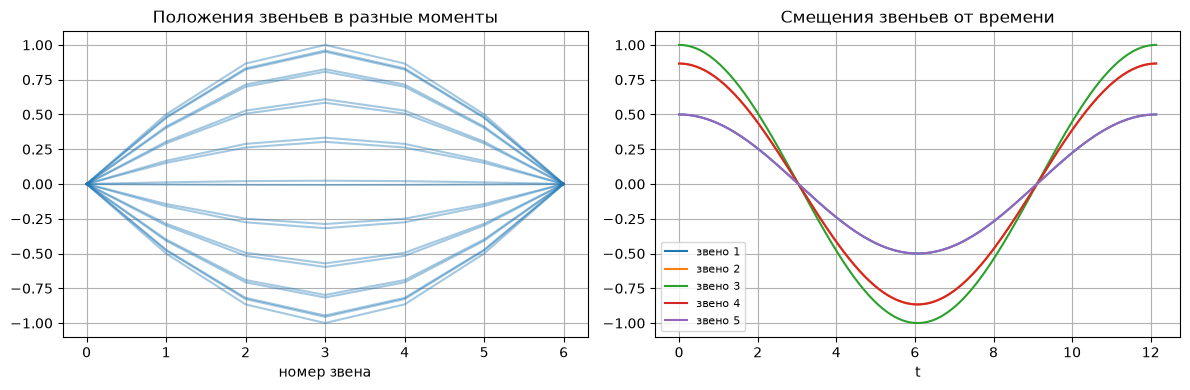

In [5]:
sys = ct.ss(A, np.zeros((2 * N, 1)), np.eye(2 * N), np.zeros((2 * N, 1)))
x0 = np.r_[shapes[0], np.zeros(N)]          # смещения по форме 1, скорости нулевые
T = np.linspace(0, 2 * np.pi / omega[0], 200)   # один период
resp = ct.initial_response(sys, T=T, X0=x0)
x = resp.outputs[:N]                         # смещения звеньев

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i in range(0, len(T), 10):
    axes[0].plot(pos, np.r_[0, x[:, i], 0], color='C0', alpha=0.4)
axes[0].set_title('Положения звеньев в разные моменты')
axes[0].set_xlabel('номер звена')
for j in range(N):
    axes[1].plot(T, x[j], label=f'звено {j + 1}')
axes[1].set_title('Смещения звеньев от времени')
axes[1].set_xlabel('t')
axes[1].legend(fontsize=8)
for a in axes:
    a.grid(True)
plt.tight_layout()
plt.show()

**Что попробовать:**
- задайте начальные условия по форме 3 или смесь двух форм и сравните графики;
- решите ту же задачу функцией `scipy.integrate.solve_ivp` (правая часть $f(t, y) = A y$);
- выполните задания 1-го блока о цепочках с разными массами $M_i = i$ (понадобится матрица масс и `scipy.linalg.eigh(K, M)`).